In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt # THIS ISN't FUNCTIONAL, IT's JUST TEMPORARY
import time
words = open('names.txt', 'r').read().splitlines()

In [2]:
class Value:
    def __init__(self, data, _children=(), _opp="", label=""):
        self.data = np.array(data)
        self.prev = set(_children)
        self.grad = np.zeros_like(self.data, dtype=float)
        self.opp = _opp
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #Make it still work if other is an integer and not a Value (a+1, for instance)
        
        def _unbroadcast(grad, shape):
            # sum over axes that were broadcast
            while grad.ndim > len(shape):
                grad = grad.sum(axis=0)
            for i, dim in enumerate(shape):
                if dim == 1:
                    grad = grad.sum(axis=i, keepdims=True)
            return grad
        
        def _backward():
            self.grad += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)

        out = Value(self.data+other.data, (self, other), "+")
        out._backward = _backward
        return out
    
    def __matmul__(self, other):
        out = Value(self.data @ other.data, (self, other), "@")
        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out = Value(self.data * other.data, (self, other), "*")
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
        #Add support for integer * Value (since 2*a doesn't work, but a*2 does)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "not an int or float"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __len__(self):
        return len(self.data)
    
    def tanh(self):
        x=self.data
        t = np.tanh(x)

        def _backward():
            self.grad += (1-t**2) * out.grad

        out = Value(t, (self, ), "tanh")
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data

        def _backward():
            self.grad += (np.exp(x)*out.data)

        out = Value(np.exp(x), (self, ), "exp")
        out._backward=_backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = np.ones_like(self.data)

        for node in reversed(topo):
            node._backward()

#Helper function
def oneHot(c):
    out = [0 for _ in range(27)]
    curIndex = ord(c)-97
    if curIndex <0:
        curIndex=26 # Change it if it's a period
    out[curIndex] = 1
    return out
def cross_entropy(logits, targets):
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    
    correct_probs = probs[np.arange(len(targets)), targets]
    loss = -np.log(correct_probs).mean()
    
    out = Value(loss, (logits,), "cross_entropy")
    
    def _backward():
        # gradient of cross entropy + softmax combined is just (probs - 1_correct) / batch_size
        dlogits = probs.copy()
        dlogits[np.arange(len(targets)), targets] -= 1
        dlogits /= len(targets)
        logits.grad += dlogits
    
    out._backward = _backward
    return out
def prog(val, total):
    length = 20
    out = "["
    for i in range(length):
        if i < math.ceil((val/total) * length):
            out += "#"
        else:
            out += "-"
    return out + "]"
def trunc(number, digits):
    stepper = 10 ** digits
    return math.trunc(number * stepper) / stepper


In [292]:
# defining weights
W1 = Value(np.random.randn(30, 200) * (5/3) / (30**0.5))  # embedding_size * block_size -> hidden
b1 = Value(np.zeros(200))
W2 = Value(np.random.randn(200, 27) * 0.01)  # hidden -> logits 
b2 = Value(np.zeros(27))
charEncodings = Value(np.random.randn(27,10)) #Increase to 10 dimensional embeddings

parameters = [charEncodings, W1, b1, W2, b2] # for easy access during 
finished = 0
lossGraph=[]

In [4]:
stoi = {s:i for i,s in enumerate(sorted(list(set(''.join(words)))))}
stoi['.']=26
itos = {i:s for s,i in stoi.items()}

blockSize = 3
inputs, outputs = [],[]

In [5]:
for w in words:
    context = [0] * blockSize # start with 3 starting characters
    for ch in w + '.':
        ix = stoi[ch] # get the current character
        inputs.append(context) # add input to inputs, output to outputs
        outputs.append(ix)
        context = context[1:] + [ix] # update the context

In [6]:
n1 = int(.8 * len(inputs))
n2 = int(.9 * len(inputs))

trainIn = inputs[:n1] # Training data (80%)
trainOut = outputs[:n1]
devIn = inputs[n1:n2] # Development data (10%)
devOut = outputs[n1:n2]
testIn = inputs[n2:] #  Test data (10%)
testOut = outputs[n2:]

In [ ]:
def forward(Value, cross_entropy, W1, b1, W2, b2, charEncodings, parameters, inputs, outputs, epoch=0):
    # Encode the inputs
    batch = [random.randint(0, len(inputs)-1) for _ in range(32)] #  get 32 random indexes (indexii? indeces? idk)

    enc = [[0 for _ in range(len(inputs[0]))] for i in range(len(batch))]
  
    for input in range(len(batch)):
        for c in range(len(inputs[batch[input]])):
            enc[input][c] = charEncodings.data[inputs[batch[input]][c]]

    #resize the inputs
    for input in range(len(enc)):
        out = []
        for letter in enc[input]:
            out.extend(letter)
        enc[input] = out

    enc = Value(enc)

    # Now for the forward pass
    h = enc @ W1 + b1 #Pre hidden layer
    h = h.tanh() # Hidden layer
    logits = h @ W2 + b2

    # Now loss calculation
    loss = cross_entropy(logits, [outputs[x] for x in batch])

    #print(loss) 

    loss.backward()

    if epoch < 150000:
        lr = -.1
    else:
        lr = -.01

    for p in parameters:
        p.data += lr * p.grad
        p.grad = np.zeros_like(p.data, dtype=float)

def forwardNoTrain(Value, cross_entropy, W1, b1, W2, b2, charEncodings, parameters, inputs, outputs, epoch=0):
    # Encode the inputs
    batch = [random.randint(0, len(inputs)-1) for _ in range(32)] #  get 32 random indexes (indexii? indeces? idk)

    enc = [[0 for _ in range(len(inputs[0]))] for i in range(len(batch))]
  
    for input in range(len(batch)):
        for c in range(len(inputs[batch[input]])):
            enc[input][c] = charEncodings.data[inputs[batch[input]][c]]

    #resize the inputs
    for input in range(len(enc)):
        out = []
        for letter in enc[input]:
            out.extend(letter)
        enc[input] = out

    enc = Value(enc)

    # Now for the forward pass
    h = enc @ W1 + b1
    h = h.tanh()
    logits = h @ W2 + b2

    # Now loss calculation
    loss = cross_entropy(logits, [outputs[x] for x in batch])

    return loss

In [293]:
epochs = 20000
START_TIME = time.perf_counter()
print(f"Started training Makemore ({epochs} epochs)")
trainTemp = -1
testTemp = -1
for i in range(epochs):
    if (i%50==0):
        train_loss = trunc(forwardNoTrain(Value, cross_entropy, W1, b1, W2, b2, charEncodings, parameters, trainIn, trainOut, i).data, 3)
        test_loss  = trunc(forwardNoTrain(Value, cross_entropy, W1, b1, W2, b2, charEncodings, parameters, testIn,  testOut,  i).data, 3)
        trainTemp, testTemp = train_loss, test_loss
        lossGraph.append(test_loss)
    else:
        train_loss = trainTemp
        test_loss = trainTemp
    elapsed_time = time.perf_counter() - START_TIME

    line1 = f"Epoch: {i+1}/{epochs} {prog(i, epochs)}"
    line2 = f"Training loss: {train_loss} Test loss: {test_loss}"
    line3 = f"{elapsed_time:.4f}s"

    # Move up two lines on every iteration except the first
    prefix = "\033[3F" if i > 0 else ""
    # print(f"{prefix}{line1}\033[K\n{line2}\033[K\n{line3}\033[K")
    forward(Value, cross_entropy, W1, b1, W2, b2, charEncodings, parameters, trainIn, trainOut, i)
    finished += 1
    print(f"\rTrained {i+1} epochs.", end="")

print(f"\nTotal Trained: {finished}")

Started training Makemore (20000 epochs)
Trained 20000 epochs.
Total Trained: 20000


In [295]:
trunc(forwardNoTrain(Value, cross_entropy, W1, b1, W2, b2, charEncodings, parameters, testIn,  testOut,  i).data, 3)

2.215

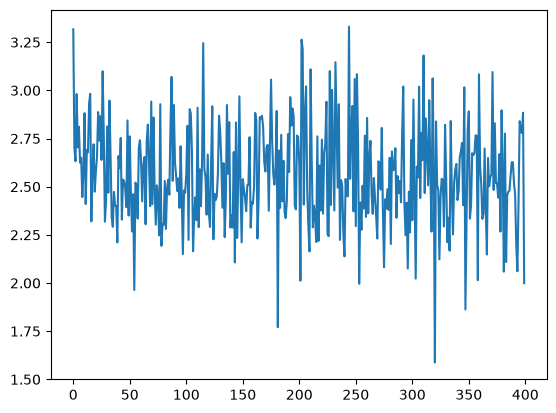

In [297]:
plt.plot(lossGraph)

In [298]:
def predict():
    out = "..."

    #First pass
    enc = [[0,0,0]]
    for c in range(3):
        enc[0][c] = charEncodings.data[26] # THis is over the top bc I didn't want to redo everything, but it just puts in the index of starting character.

    #resize the inputs
    for input in range(len(enc)):
        flat = []
        for letter in enc[input]:
            flat.extend(letter)
        enc[input] = flat

    enc = Value(enc)

    h = enc @ W1 + b1
    h = h.tanh()
    logits = h @ W2 + b2
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    reverse = {v: k for k, v in stoi.items()}

    while len(out) < 50:
        # rest of name
        enc = [[0,0,0]]
        for c in range(3):
            enc[0][c] = charEncodings.data[stoi[out[-3+c]]]

        #resize the inputs
        for input in range(len(enc)):
            flat = []
            for letter in enc[input]:
                flat.extend(letter)
            enc[input] = flat

        enc = Value(enc)

        h = enc @ W1 + b1
        h = h.tanh()
        logits = h @ W2 + b2
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        reverse = {v: k for k, v in stoi.items()} 
        out += reverse[np.random.choice(27, p=probs[0])]
        if out[-1] == '.':
            break
    
    print(out[3:-1])

In [302]:
for i in range(20):
    predict()

qhen
rqien
n
n
lyn
vtua
r

n

figgo
klllidith
n
nylazzy
dyn
ni
nlyan
n
n
ristumahaylia
